# Panel cumulative local projections IV: CPI on xi x oil

This notebook estimates cumulative panel LP-IV using quarterly CPI inflation.

It mirrors `panel_cumulative_local_projections.ipynb`, but estimates 2SLS local projections with:

- Endogenous shock: `xi_x_oil`
- Instrument: `xi_x_news`
- Outcome: quarterly CPI inflation (`cpi_pct_change`)


In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [11]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
annual_cpi_path = ROOT / "data/processed/cpi/annual_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
news_path = ROOT / "data/processed/oil/kaenzig_oil_supply_surprises_quarterly.csv"
news_column = "news_shock"  # "news_shock" or "surprise"
cpi_freq = "Q"

zeta_path = ROOT / "data/processed/zeta/regular/zeta_by_country_year.parquet"
zeta_x_oil2_col = "zeta_x_oil2"
zeta_x_news2_col = "zeta_x_news2"
news2_col = "news2"
base_regression_controls = ["exchange_rate", "output_gap", "policy_rate"]

panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    }
]

horizons = 11
y_lags = 3
shock_lags = 3
base_control_lags = {"exchange_rate": 3, "output_gap": 3, "policy_rate": 3}
include_country_fe = True
include_time_fe = False
cov_type = "cluster_country_time"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None
use_annual_cpi_for_full_year_horizons = False
lag_xi_by_one_year_for_xi_x_oil = True
lag_zeta_by_one_year_for_zeta_x_oil2 = True

iv_controls = [zeta_x_oil2_col, *base_regression_controls]
iv_control_lags = {zeta_x_oil2_col: shock_lags, **base_control_lags}
oil2_iv_controls = ["xi_x_oil", *base_regression_controls]
oil2_iv_control_lags = {"xi_x_oil": shock_lags, **base_control_lags}

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("include_country_fe:", include_country_fe)
print("include_time_fe:", include_time_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("base_regression_controls:", base_regression_controls)
print("iv_controls:", iv_controls)
print("iv_control_lags:", iv_control_lags)
print("oil2_iv_controls:", oil2_iv_controls)
print("oil2_iv_control_lags:", oil2_iv_control_lags)
print("use_annual_cpi_for_full_year_horizons:", use_annual_cpi_for_full_year_horizons)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)
print("lag_zeta_by_one_year_for_zeta_x_oil2:", lag_zeta_by_one_year_for_zeta_x_oil2)
print("news_path:", news_path)
print("news_column:", news_column)


horizons: 11
y_lags: 3
shock_lags: 3
include_country_fe: True
include_time_fe: False
cov_type: cluster_country
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate']
base_regression_controls: ['exchange_rate', 'output_gap', 'policy_rate']
iv_controls: ['zeta_x_oil2', 'exchange_rate', 'output_gap', 'policy_rate']
iv_control_lags: {'zeta_x_oil2': 3, 'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
oil2_iv_controls: ['xi_x_oil', 'exchange_rate', 'output_gap', 'policy_rate']
oil2_iv_control_lags: {'xi_x_oil': 3, 'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
use_annual_cpi_for_full_year_horizons: False
lag_xi_by_one_year_for_xi_x_oil: True
lag_zeta_by_one_year_for_zeta_x_oil2: True
news_path: C:\Users\user\projects\academics\0_diss\analysis\data\processed\oil\kaenzig_oil_supply_surprises_quarterly.csv
news_column: news_shock


In [ ]:
def load_annual_cpi(path: Path) -> pd.DataFrame:
    annual = lp.regression.load_cpi_pct_change(path, freq="A")
    annual = annual.rename(columns={"cpi_pct_change": "annual_cpi_pct_change"})
    return annual


def add_cumulative_targets(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    horizons: int = 8,
    annual_cpi_df: pd.DataFrame | None = None,
    use_annual_override: bool = False,
) -> pd.DataFrame:
    out = df.copy().sort_values(["country", "time_index"]).reset_index(drop=True)
    if "period" not in out.columns:
        raise ValueError("Quarterly cumulative LP requires a 'period' column.")

    period_parts = out["period"].astype(str).str.extract(r"^(\d{4})-Q([1-4])$")
    out["period_year"] = pd.to_numeric(period_parts[0], errors="coerce")
    out["period_quarter"] = pd.to_numeric(period_parts[1], errors="coerce")
    if out[["period_year", "period_quarter"]].isna().any().any():
        raise ValueError("Could not parse year/quarter from the quarterly period labels.")
    out["period_year"] = out["period_year"].astype(int)
    out["period_quarter"] = out["period_quarter"].astype(int)

    if annual_cpi_df is not None:
        annual_lookup = annual_cpi_df.copy()
    else:
        annual_lookup = None

    for horizon in range(horizons + 1):
        target_col = f"cum_cpi_lead{horizon}"
        out[target_col] = 0.0
        for step in range(horizon + 1):
            shifted = out.groupby("country")[y_col].shift(-step)
            out[target_col] = shifted if step == 0 else out[target_col] + shifted

        if use_annual_override and annual_lookup is not None and (horizon + 1) % 4 == 0:
            end_year_col = f"end_year_h{horizon}"
            end_quarter_col = f"end_quarter_h{horizon}"
            out[end_year_col] = out.groupby("country")["period_year"].shift(-horizon)
            out[end_quarter_col] = out.groupby("country")["period_quarter"].shift(-horizon)
            aligned = (out["period_quarter"] == 1) & (out[end_quarter_col] == 4)
            annual_rows = []
            years_in_window = (horizon + 1) // 4
            for year_offset in range(years_in_window):
                year_col = f"annual_year_h{horizon}_{year_offset}"
                value_col = f"annual_cpi_h{horizon}_{year_offset}"
                out[year_col] = out["period_year"] + year_offset
                merged = out[["country", year_col]].merge(
                    annual_lookup,
                    left_on=["country", year_col],
                    right_on=["country", "year"],
                    how="left",
                )
                out[value_col] = merged["annual_cpi_pct_change"].values
                annual_rows.append(value_col)
            annual_sum = out[annual_rows].sum(axis=1, min_count=years_in_window)
            out[target_col] = out[target_col].where(~aligned, annual_sum)

    return out


def fit_cumulative_panel_local_projections(
    df: pd.DataFrame,
    *,
    y_col: str = "cpi_pct_change",
    shock_col: str = "xi_x_oil",
    horizons: int = 8,
    y_lags: int = 4,
    shock_lags: int = 0,
    controls: list[str] | None = None,
    control_lags: int | dict[str, int] = 0,
    include_country_fe: bool = True,
    include_time_fe: bool = True,
    cov_type: str = "cluster_country",
) -> tuple[pd.DataFrame, pd.DataFrame, dict[int, object]]:
    controls = controls or []
    required = {"country", "time_index", y_col, shock_col, *controls}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing cumulative LP columns: {sorted(missing)}")

    target_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
    missing_targets = sorted(set(target_cols) - set(df.columns))
    if missing_targets:
        raise ValueError(f"Missing cumulative target columns: {missing_targets}")

    work = df[["country", "time_index", "year", "period", y_col, shock_col, *controls, *target_cols]].copy()
    work = work.sort_values(["country", "time_index"]).reset_index(drop=True)

    y_lag_cols = []
    for lag in range(1, y_lags + 1):
        col = f"{y_col}_lag{lag}"
        work[col] = work.groupby("country")[y_col].shift(lag)
        y_lag_cols.append(col)

    shock_lag_cols = []
    for lag in range(1, shock_lags + 1):
        col = f"{shock_col}_lag{lag}"
        work[col] = work.groupby("country")[shock_col].shift(lag)
        shock_lag_cols.append(col)

    control_cols = []
    for control in controls:
        #control_cols.append(control)
        lag_count = control_lags[control] if isinstance(control_lags, dict) else int(control_lags)
        for lag in range(1, lag_count + 1):
            col = f"{control}_lag{lag}"
            work[col] = work.groupby("country")[control].shift(lag)
            control_cols.append(col)

    irf_rows = []
    coef_rows = []
    models = {}

    for horizon in range(horizons + 1):
        dep_col = f"cum_cpi_lead{horizon}"

        x_cols = [shock_col, *shock_lag_cols, *y_lag_cols, *control_cols]
        x_base = work[x_cols].copy()
        fe_cols = []

        if include_country_fe:
            country_fe = pd.get_dummies(work["country"], prefix="country_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, country_fe], axis=1)
            fe_cols.extend(country_fe.columns.tolist())

        if include_time_fe:
            time_fe = pd.get_dummies(work["time_index"], prefix="time_fe", drop_first=True, dtype=float)
            x_base = pd.concat([x_base, time_fe], axis=1)
            fe_cols.extend(time_fe.columns.tolist())

        design = pd.concat([work[["country", "year", "period", dep_col]], x_base], axis=1).dropna().reset_index(drop=True)
        if design.empty:
            raise ValueError(
                "No rows left for cumulative local projections after target, lag, and missing-data filters. "
                f"horizon={horizon}, y_lags={y_lags}, shock_lags={shock_lags}."
            )

        y = pd.to_numeric(design[dep_col], errors="coerce")
        x = sm.add_constant(design[x_cols + fe_cols], has_constant="add")
        base_model = sm.OLS(y, x, missing="raise")
        if cov_type == "cluster_country":
            model = base_model.fit(cov_type="cluster", cov_kwds={"groups": design["country"]})
            std_err_col = "std_err_cluster_country"
        elif cov_type == "hc3":
            model = base_model.fit(cov_type="HC3")
            std_err_col = "std_err_hc3"
        else:
            raise ValueError(f"Unsupported cov_type '{cov_type}'.")

        models[horizon] = model
        ci = model.conf_int()
        coef_df = pd.DataFrame(
            {
                "horizon": horizon,
                "term": model.params.index,
                "coef": model.params.values,
                std_err_col: model.bse.values,
                "t": model.tvalues.values,
                "p_value": model.pvalues.values,
                "ci_low_95": ci.iloc[:, 0].values,
                "ci_high_95": ci.iloc[:, 1].values,
                "nobs": float(model.nobs),
            }
        )
        coef_rows.extend(coef_df.to_dict(orient="records"))

        shock_row = coef_df.loc[coef_df["term"] == shock_col]
        irf_rows.append(
            {
                "horizon": horizon,
                "term": shock_col,
                "coef": float(shock_row["coef"].iloc[0]),
                std_err_col: float(shock_row[std_err_col].iloc[0]),
                "t": float(shock_row["t"].iloc[0]),
                "p_value": float(shock_row["p_value"].iloc[0]),
                "ci_low_95": float(shock_row["ci_low_95"].iloc[0]),
                "ci_high_95": float(shock_row["ci_high_95"].iloc[0]),
                "nobs": float(model.nobs),
                "n_countries": int(design["country"].nunique()),
            }
        )

    return pd.DataFrame(irf_rows), pd.DataFrame(coef_rows), models


In [13]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    news_path=news_path,
    news_column=news_column,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

zeta_df = pd.read_parquet(zeta_path)
zeta_df = zeta_df.loc[zeta_df["status"] == "ok", ["country", "year", "zeta"]].copy()
zeta_df["year"] = pd.to_numeric(zeta_df["year"], errors="coerce")
zeta_df["zeta"] = pd.to_numeric(zeta_df["zeta"], errors="coerce")
zeta_df = zeta_df.dropna(subset=["country", "year", "zeta"])
zeta_df["year"] = zeta_df["year"].astype(int)
zeta_df = zeta_df.sort_values(["country", "year"]).reset_index(drop=True)
if lag_zeta_by_one_year_for_zeta_x_oil2:
    zeta_df["zeta_for_interactions"] = zeta_df.groupby("country")["zeta"].shift(1)
else:
    zeta_df["zeta_for_interactions"] = zeta_df["zeta"]

panel_df = panel_df.merge(
    zeta_df[["country", "year", "zeta", "zeta_for_interactions"]],
    on=["country", "year"],
    how="left",
    validate="many_to_one",
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,7522,80,1995,2022,23.625,1995-Q1,2022-Q4,94.025


In [14]:
panel_df_model = panel_df.copy()
panel_df_model[zeta_x_oil2_col] = panel_df_model["zeta_for_interactions"] * (panel_df_model["oil_pct_change"] ** 2)
panel_df_model[news2_col] = panel_df_model["news"] ** 2
panel_df_model[zeta_x_news2_col] = panel_df_model["zeta_for_interactions"] * panel_df_model[news2_col]

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

annual_cpi_df = load_annual_cpi(annual_cpi_path)
panel_df_model = lp.build_cumulative_targets(
    panel_df_model,
    y_col="cpi_pct_change",
    horizons=horizons,
    annual_cpi_df=annual_cpi_df,
    use_annual_override=use_annual_cpi_for_full_year_horizons,
)

panel_df_model[["country", "period", "zeta", "zeta_for_interactions", "oil_pct_change", zeta_x_oil2_col, "news", news2_col, zeta_x_news2_col, "xi_x_oil", "xi_x_news"]].head()


CPI outlier filter disabled.
Rows kept: 7522


,country,period,zeta,zeta_for_interactions,oil_pct_change,zeta_x_oil2,news,news2,zeta_x_news2,xi_x_oil,xi_x_news
0,AGO,2002-Q2,0.019255,0.014623,0.189848,0.000527,-0.452902,0.205120,0.002999,0.007227,-0.017241
1,AGO,2002-Q3,0.019255,0.014623,0.066242,0.000064,0.865002,0.748229,0.010941,0.002522,0.032929
2,AGO,2002-Q4,0.019255,0.014623,-0.011465,0.000002,0.675704,0.456576,0.006676,-0.000436,0.025723
3,AGO,2003-Q1,0.029201,0.019255,0.162677,0.000510,0.924390,0.854497,0.016453,0.013974,0.079403
4,AGO,2003-Q2,0.029201,0.019255,-0.167036,0.000537,-0.782905,0.612940,0.011802,-0.014348,-0.067250


In [15]:
cum_cols = [f"cum_cpi_lead{h}" for h in range(horizons + 1)]
panel_df_model[["country", "period", "cpi_pct_change", *cum_cols]].head(12)


,country,period,cpi_pct_change,cum_cpi_lead0,cum_cpi_lead1,cum_cpi_lead2,cum_cpi_lead3,cum_cpi_lead4,cum_cpi_lead5,cum_cpi_lead6,cum_cpi_lead7,cum_cpi_lead8,cum_cpi_lead9,cum_cpi_lead10,cum_cpi_lead11
0,AGO,2002-Q2,0.171750,0.171750,0.381272,0.560691,0.794783,0.995316,1.136748,1.219820,1.318576,1.405436,1.464548,1.517118,1.579593
1,AGO,2002-Q3,0.209522,0.209522,0.388942,0.623033,0.823566,0.964998,1.048071,1.146827,1.233687,1.292798,1.345368,1.407844,1.454514
2,AGO,2002-Q4,0.179419,0.179419,0.413511,0.614044,0.755476,0.838549,0.937305,1.024164,1.083276,1.135846,1.198321,1.244992,1.279011
3,AGO,2003-Q1,0.234092,0.234092,0.434624,0.576057,0.659129,0.757885,0.844745,0.903857,0.956426,1.018902,1.065572,1.099592,1.135296
4,AGO,2003-Q2,0.200532,0.200532,0.341965,0.425037,0.523793,0.610653,0.669765,0.722334,0.784810,0.831481,0.865500,0.901204,0.933960
5,AGO,2003-Q3,0.141433,0.141433,0.224505,0.323261,0.410121,0.469233,0.521802,0.584278,0.630948,0.664968,0.700671,0.733427,0.757690
6,AGO,2003-Q4,0.083072,0.083072,0.181828,0.268688,0.327800,0.380369,0.442845,0.489516,0.523535,0.559239,0.591995,0.616258,0.641487
7,AGO,2004-Q1,0.098756,0.098756,0.185616,0.244728,0.297297,0.359773,0.406443,0.440463,0.476166,0.508922,0.533185,0.558414,0.591883
8,AGO,2004-Q2,0.086860,0.086860,0.145972,0.198541,0.261017,0.307687,0.341707,0.377410,0.410166,0.434429,0.459659,0.493127,0.527933
9,AGO,2004-Q3,0.059112,0.059112,0.111681,0.174157,0.220827,0.254847,0.290550,0.323306,0.347569,0.372799,0.406267,0.441073,0.465827


In [7]:
iv_irf_df, iv_coef_df, iv_models = lp.fit_cumulative_panel_local_projections_iv(
    panel_df_model,
    y_col="cpi_pct_change",
    endog_col="xi_x_oil",
    instrument_col="xi_x_news",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=iv_controls,
    control_lags=iv_control_lags,
    include_country_fe=include_country_fe,
    include_time_fe=include_time_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

oil2_iv_irf_df, oil2_iv_coef_df, oil2_iv_models = lp.fit_cumulative_panel_local_projections_iv(
    panel_df_model,
    y_col="cpi_pct_change",
    endog_col=zeta_x_oil2_col,
    instrument_col=zeta_x_news2_col,
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=oil2_iv_controls,
    control_lags=oil2_iv_control_lags,
    include_country_fe=include_country_fe,
    include_time_fe=include_time_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

pd.concat(
    {
        "xi_x_oil_iv": iv_irf_df.set_index("horizon"),
        "oil2_iv": oil2_iv_irf_df.set_index("horizon"),
    },
    names=["shock", "horizon"],
).reset_index()


,shock,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,xi_x_oil_iv,0,xi_x_oil,0.303145,0.080755,3.753903,0.000462,0.140862,0.465427,3528.0,50
1,xi_x_oil_iv,1,xi_x_oil,0.646733,0.155755,4.152240,0.000131,0.333731,0.959735,3528.0,50
2,xi_x_oil_iv,2,xi_x_oil,0.483788,0.151256,3.198474,0.002423,0.179828,0.787749,3528.0,50
3,xi_x_oil_iv,3,xi_x_oil,0.398065,0.195738,2.033656,0.047420,0.004714,0.791416,3528.0,50
4,xi_x_oil_iv,4,xi_x_oil,0.402816,0.223002,1.806332,0.077010,-0.045324,0.850955,3528.0,50
5,xi_x_oil_iv,5,xi_x_oil,0.244027,0.269267,0.906265,0.369231,-0.297085,0.785139,3528.0,50
6,xi_x_oil_iv,6,xi_x_oil,0.166926,0.331173,0.504044,0.616489,-0.498592,0.832444,3528.0,50
7,xi_x_oil_iv,7,xi_x_oil,0.144268,0.369407,0.390541,0.697830,-0.598082,0.886619,3528.0,50
8,xi_x_oil_iv,8,xi_x_oil,0.083051,0.408753,0.203182,0.839834,-0.738368,0.904471,3528.0,50
9,xi_x_oil_iv,9,xi_x_oil,-0.027436,0.455560,-0.060224,0.952222,-0.942918,0.888047,3528.0,50


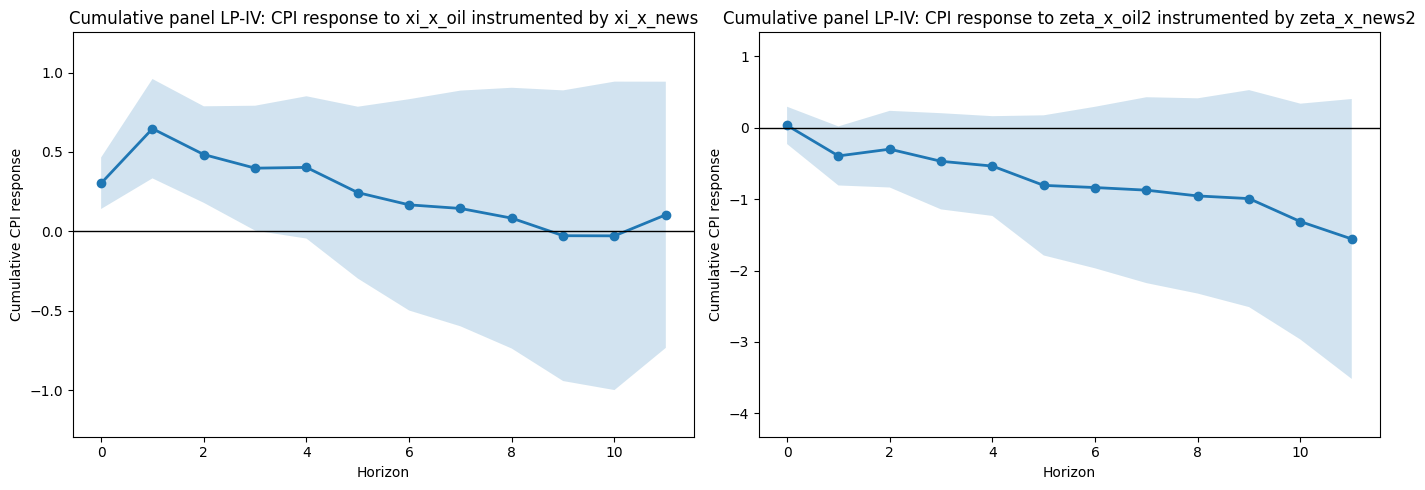

In [8]:
def set_irf_axis_limits(ax, irf_df, *, pad_ratio: float = 0.15, min_pad: float = 0.01):
    y_min = float(irf_df["ci_low_95"].min())
    y_max = float(irf_df["ci_high_95"].max())
    span = y_max - y_min
    pad = max(span * pad_ratio, min_pad)
    ax.set_ylim(y_min - pad, y_max + pad)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lp.plot_irf(
    iv_irf_df,
    title="Cumulative panel LP-IV: CPI response to xi_x_oil instrumented by xi_x_news",
    ax=axes[0],
)
set_irf_axis_limits(axes[0], iv_irf_df)
axes[0].set_ylabel("Cumulative CPI response")

lp.plot_irf(
    oil2_iv_irf_df,
    title="Cumulative panel LP-IV: CPI response to zeta_x_oil2 instrumented by zeta_x_news2",
    ax=axes[1],
)
set_irf_axis_limits(axes[1], oil2_iv_irf_df, pad_ratio=0.2, min_pad=0.05)
axes[1].set_ylabel("Cumulative CPI response")

plt.tight_layout()
plt.show()


In [9]:
horizon_to_inspect = 0
print("xi_x_oil IV specification")
print(iv_models[horizon_to_inspect].summary())

print("\n" + "=" * 80 + "\n")
print("zeta_x_oil2 IV specification")
print(oil2_iv_models[horizon_to_inspect].summary())


xi_x_oil IV specification
                          IV2SLS Regression Results                           
Dep. Variable:          cum_cpi_lead0   R-squared:                       0.528
Model:                         IV2SLS   Adj. R-squared:                  0.519
Method:                     Two Stage   F-statistic:                     82.49
                        Least Squares   Prob (F-statistic):               0.00
Date:                Sun, 05 Apr 2026                                         
Time:                        14:37:59                                         
No. Observations:                3528                                         
Df Residuals:                    3455                                         
Df Model:                          72                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const   

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 72, but rank is 23
  warnings.warn('covariance of constraints does not have full '
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 72, but rank is 23
  warnings.warn('covariance of constraints does not have full '
